# Retail Business Performance & Profitability Analysis

## Project Objective

Analyze retail transaction data to identify sales and profitability
patterns, evaluate product and regional performance, identify
profit-draining areas, and generate actionable business insights.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SQL
- Tableau


In [ ]:
# ==========================================
# SETUP & LOAD DATASET
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Upload dataset
from google.colab import files

uploaded = files.upload()

# Load uploaded CSV
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("File:", filename)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Saving Sample-Superstore.csv to Sample-Superstore.csv
Dataset loaded successfully!
File: Sample-Superstore.csv
Rows: 9994
Columns: 22


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv("train.csv")

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [ ]:
df = pd.read_csv("train.csv")

In [ ]:
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("File:", filename)

Dataset loaded successfully!
File: train.csv


In [ ]:
df.shape

(9800, 18)

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Sample-Superstore.csv to Sample-Superstore.csv


In [ ]:
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("File:", filename)

Dataset loaded successfully!
File: Sample-Superstore.csv


In [ ]:
df.shape

(9994, 22)

In [ ]:
df.columns

Index(['csvbase_row_id', '﻿Row ID', 'Order ID', 'Order Date', 'Ship Date',
       'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country',
       'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [ ]:
df.head()

,csvbase_row_id,﻿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
print("Columns in dataset:")
for i, column in enumerate(df.columns):
    print(i, ":", column)

Columns in dataset:
0 : csvbase_row_id
1 : ﻿Row ID
2 : Order ID
3 : Order Date
4 : Ship Date
5 : Ship Mode
6 : Customer ID
7 : Customer Name
8 : Segment
9 : Country
10 : City
11 : State
12 : Postal Code
13 : Region
14 : Product ID
15 : Category
16 : Sub-Category
17 : Product Name
18 : Sales
19 : Quantity
20 : Discount
21 : Profit


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

uploaded = files.upload()

Saving Sample-Superstore.csv to Sample-Superstore.csv


In [ ]:
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("File:", filename)
print("Shape:", df.shape)

Dataset loaded successfully!
File: Sample-Superstore.csv
Shape: (9994, 22)


In [ ]:
print("========== DATASET OVERVIEW ==========\n")

print("Shape:", df.shape)

print("\n========== COLUMNS ==========\n")
print(df.columns.tolist())

print("\n========== DATA TYPES ==========\n")
print(df.dtypes)

print("\n========== MISSING VALUES ==========\n")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n========== DUPLICATE ROWS ==========\n")
print("Duplicates:", df.duplicated().sum())

print("\n========== NUMERICAL SUMMARY ==========\n")
display(df.describe().T)

========== DATASET OVERVIEW ==========

Shape: (9994, 22)

========== COLUMNS ==========

['csvbase_row_id', '\ufeffRow ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

========== DATA TYPES ==========

csvbase_row_id      int64
﻿Row ID             int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
Country            object
City               object
State              object
Postal Code         int64
Region             object
Product ID         object
Category           object
Sub-Category       object
Product Name       object
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
dtype: object

====

,count,mean,std,min,25%,50%,75%,max
csvbase_row_id,9994.0,4997.500000,2885.163629,1.000,2499.25000,4997.5000,7495.750,9994.000
﻿Row ID,9994.0,4997.500000,2885.163629,1.000,2499.25000,4997.5000,7495.750,9994.000
Postal Code,9994.0,55190.379428,32063.693350,1040.000,23223.00000,56430.5000,90008.000,99301.000
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976


In [ ]:
df.head()

,csvbase_row_id,﻿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   csvbase_row_id  9994 non-null   int64  
 1   ﻿Row ID         9994 non-null   int64  
 2   Order ID        9994 non-null   object 
 3   Order Date      9994 non-null   object 
 4   Ship Date       9994 non-null   object 
 5   Ship Mode       9994 non-null   object 
 6   Customer ID     9994 non-null   object 
 7   Customer Name   9994 non-null   object 
 8   Segment         9994 non-null   object 
 9   Country         9994 non-null   object 
 10  City            9994 non-null   object 
 11  State           9994 non-null   object 
 12  Postal Code     9994 non-null   int64  
 13  Region          9994 non-null   object 
 14  Product ID      9994 non-null   object 
 15  Category        9994 non-null   object 
 16  Sub-Category    9994 non-null   object 
 17  Product Name    9994 non-null   o

In [ ]:
missing = df.isnull().sum()

print("Missing Values:")
print(missing[missing > 0])

Missing Values:
Series([], dtype: int64)


In [ ]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [ ]:
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976


In [ ]:
print("Sales <= 0:", (df['Sales'] <= 0).sum())

Sales <= 0: 0


In [ ]:
print("Quantity <= 0:", (df['Quantity'] <= 0).sum())

Quantity <= 0: 0


In [ ]:
print("Discount < 0:", (df['Discount'] < 0).sum())
print("Discount > 1:", (df['Discount'] > 1).sum())

Discount < 0: 0
Discount > 1: 0


In [ ]:
print("Profit is missing:", df['Profit'].isnull().sum())

Profit is missing: 0


In [ ]:
df[['Order Date', 'Ship Date']].dtypes

,0
Order Date,object
Ship Date,object


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

In [ ]:
df[['Order Date', 'Ship Date']].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


In [ ]:
print("Invalid Order Dates:", df['Order Date'].isnull().sum())
print("Invalid Ship Dates:", df['Ship Date'].isnull().sum())

Invalid Order Dates: 0
Invalid Ship Dates: 0


In [ ]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.month_name()
df['Order Quarter'] = df['Order Date'].dt.quarter

In [ ]:
df[['Order Date',
    'Order Year',
    'Order Month',
    'Order Month Name',
    'Order Quarter']].head()

,Order Date,Order Year,Order Month,Order Month Name,Order Quarter
0,2016-11-08,2016,11,November,4
1,2016-11-08,2016,11,November,4
2,2016-06-12,2016,6,June,2
3,2015-10-11,2015,10,October,4
4,2015-10-11,2015,10,October,4


In [ ]:
df['Shipping Days'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

In [ ]:
df[['Order Date', 'Ship Date', 'Shipping Days']].head()

,Order Date,Ship Date,Shipping Days
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


In [ ]:
df['Shipping Days'].describe()

,Shipping Days
count,9994.000000
mean,3.958175
std,1.747567
min,0.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,7.000000


In [ ]:
df.drop(columns=['csvbase_row_id'], inplace=True)

In [ ]:
print("Number of columns:", df.shape[1])

Number of columns: 26


In [ ]:
missing = df.isnull().sum()

print("Missing values:")
print(missing[missing > 0])

Missing values:
Series([], dtype: int64)


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
print("Sales <= 0:", (df['Sales'] <= 0).sum())
print("Quantity <= 0:", (df['Quantity'] <= 0).sum())
print("Discount < 0:", (df['Discount'] < 0).sum())
print("Discount > 1:", (df['Discount'] > 1).sum())
print("Profit missing:", df['Profit'].isnull().sum())

Sales <= 0: 0
Quantity <= 0: 0
Discount < 0: 0
Discount > 1: 0
Profit missing: 0


In [ ]:
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976


In [ ]:
print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [ ]:
print("Negative shipping days:", (df['Shipping Days'] < 0).sum())

Negative shipping days: 0


In [ ]:
missing = df.isnull().sum()
print(missing[missing > 0])

Series([], dtype: int64)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Sample-Superstore.csv to Sample-Superstore (1).csv


In [ ]:
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("File:", filename)
print("Shape:", df.shape)

Dataset loaded successfully!
File: Sample-Superstore.csv
Shape: (9994, 22)


In [ ]:
# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

# Create time-based features
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.month_name()
df['Order Quarter'] = df['Order Date'].dt.quarter

# Calculate shipping duration
df['Shipping Days'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

print("Date conversion and feature creation completed!")

Date conversion and feature creation completed!


In [ ]:
df.drop(columns=['csvbase_row_id'], inplace=True)

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9994
Columns: 26


In [ ]:
print("========== MISSING VALUES ==========")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n========== DUPLICATES ==========")
print("Duplicate rows:", df.duplicated().sum())

print("\n========== INVALID VALUES ==========")
print("Sales <= 0:", (df['Sales'] <= 0).sum())
print("Quantity <= 0:", (df['Quantity'] <= 0).sum())
print("Discount < 0:", (df['Discount'] < 0).sum())
print("Discount > 1:", (df['Discount'] > 1).sum())
print("Profit missing:", df['Profit'].isnull().sum())

print("\n========== SHIPPING ==========")
print("Negative shipping days:", (df['Shipping Days'] < 0).sum())

========== MISSING VALUES ==========
Series([], dtype: int64)

========== DUPLICATES ==========
Duplicate rows: 0

========== INVALID VALUES ==========
Sales <= 0: 0
Quantity <= 0: 0
Discount < 0: 0
Discount > 1: 0
Profit missing: 0

========== SHIPPING ==========
Negative shipping days: 0


In [ ]:
df[['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Days']].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976
Shipping Days,9994.0,3.958175,1.747567,0.000,3.00000,4.0000,5.000,7.000


In [ ]:
category_performance = df.groupby('Category').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).sort_values('Sales', ascending=False)

category_performance

,Sales,Profit,Quantity
Category,,,
Technology,836154.0330,145454.9481,6939
Furniture,741999.7953,18451.2728,8028
Office Supplies,719047.0320,122490.8008,22906


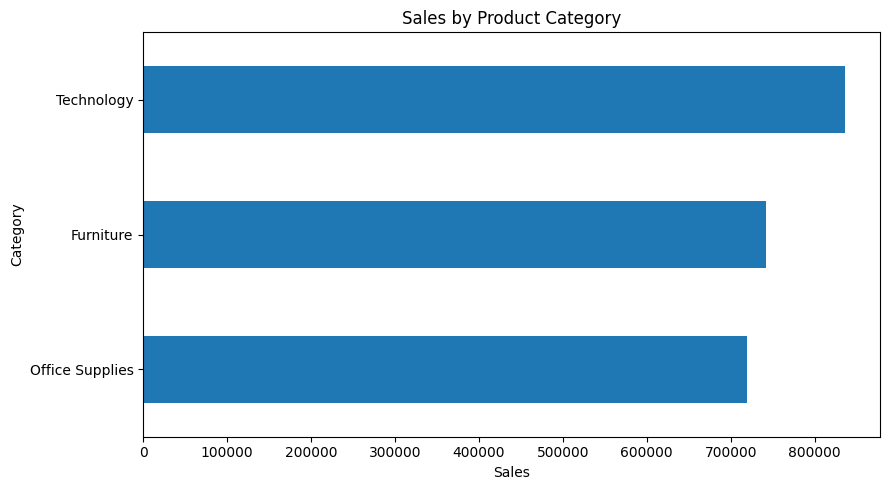

In [ ]:
plt.figure(figsize=(9, 5))

category_performance['Sales'].sort_values().plot(
    kind='barh'
)

plt.title('Sales by Product Category')
plt.xlabel('Sales')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

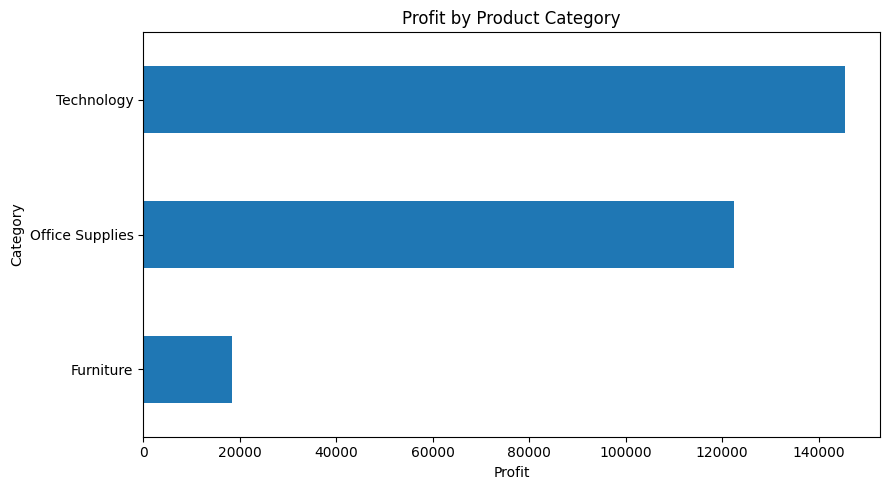

In [ ]:
plt.figure(figsize=(9, 5))

category_performance['Profit'].sort_values().plot(
    kind='barh'
)

plt.title('Profit by Product Category')
plt.xlabel('Profit')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [ ]:
monthly_sales = df.groupby(
    ['Order Year', 'Order Month']
).agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()

monthly_sales['Year-Month'] = (
    monthly_sales['Order Year'].astype(str)
    + '-'
    + monthly_sales['Order Month'].astype(str).str.zfill(2)
)

monthly_sales.head()

,Order Year,Order Month,Sales,Profit,Year-Month
0,2014,1,14236.895,2450.1907,2014-01
1,2014,2,4519.892,862.3084,2014-02
2,2014,3,55691.009,498.7299,2014-03
3,2014,4,28295.345,3488.8352,2014-04
4,2014,5,23648.287,2738.7096,2014-05


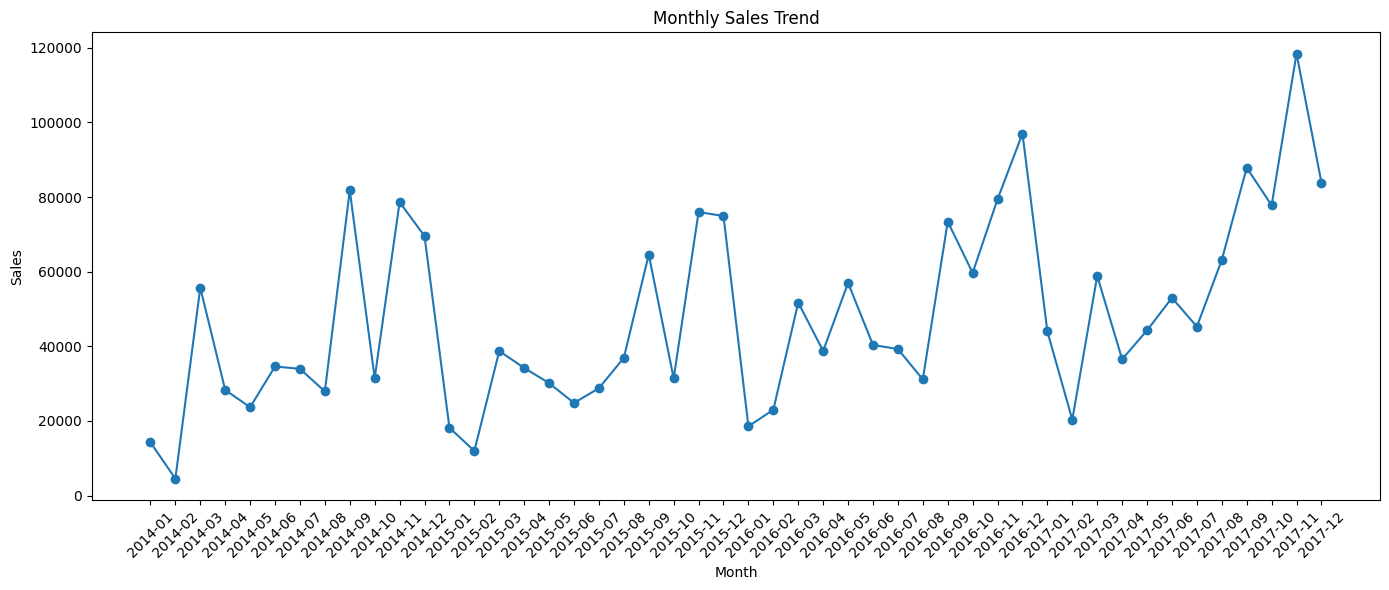

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales['Year-Month'],
    monthly_sales['Sales'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
region_performance = df.groupby('Region').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).sort_values('Sales', ascending=False)

region_performance

,Sales,Profit,Quantity
Region,,,
West,725457.8245,108418.4489,12266
East,678781.2400,91522.7800,10618
Central,501239.8908,39706.3625,8780
South,391721.9050,46749.4303,6209


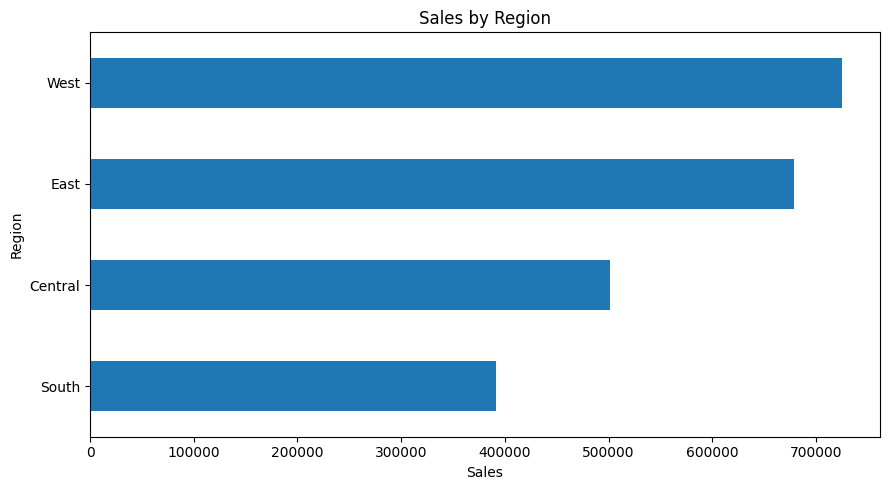

In [ ]:
plt.figure(figsize=(9, 5))

region_performance['Sales'].sort_values().plot(
    kind='barh'
)

plt.title('Sales by Region')
plt.xlabel('Sales')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

In [ ]:
subcategory_profit = df.groupby('Sub-Category').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).sort_values('Profit')

subcategory_profit

,Sales,Profit,Quantity
Sub-Category,,,
Tables,206965.5320,-17725.4811,1241
Bookcases,114879.9963,-3472.5560,868
Supplies,46673.5380,-1189.0995,647
Fasteners,3024.2800,949.5182,914
Machines,189238.6310,3384.7569,440
Labels,12486.3120,5546.2540,1400
Art,27118.7920,6527.7870,3000
Envelopes,16476.4020,6964.1767,906
Furnishings,91705.1640,13059.1436,3563


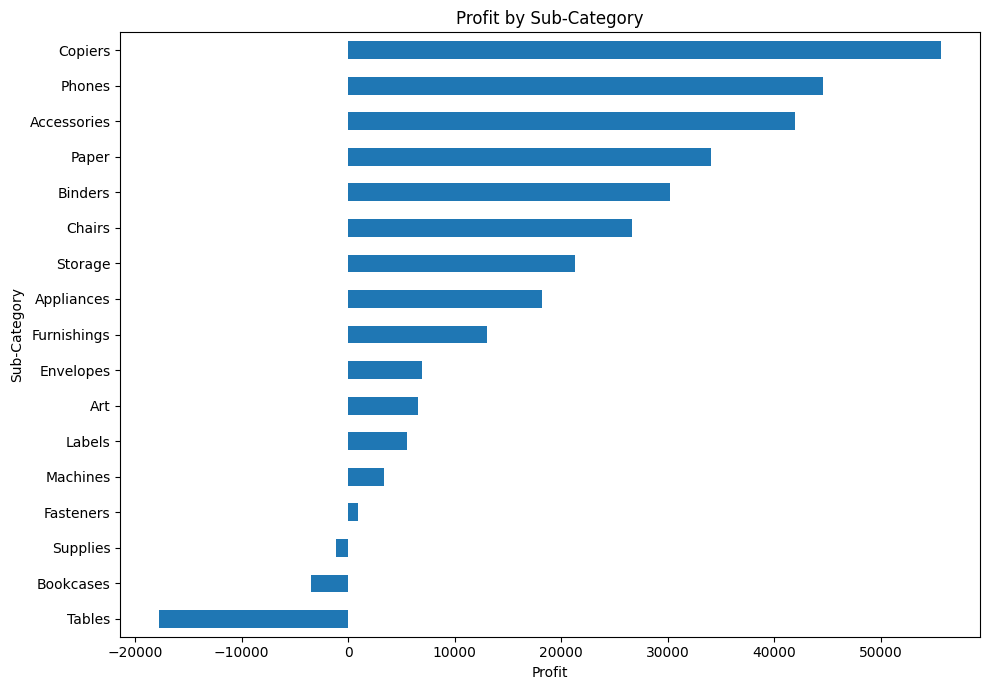

In [ ]:
plt.figure(figsize=(10, 7))

subcategory_profit['Profit'].plot(
    kind='barh'
)

plt.title('Profit by Sub-Category')
plt.xlabel('Profit')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()

In [ ]:
discount_profit = df.groupby('Discount').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).reset_index()

discount_profit

,Discount,Sales,Profit,Quantity
0,0.00,1.087908e+06,320987.6032,18267
1,0.10,5.436935e+04,9029.1770,373
2,0.15,2.755852e+04,1418.9915,198
3,0.20,7.645944e+05,90337.3060,13660
4,0.30,1.032267e+05,-10369.2774,849
5,0.32,1.449346e+04,-2391.1377,105
6,0.40,1.164178e+05,-23057.0504,786
7,0.45,5.484974e+03,-2493.1111,45
8,0.50,5.891854e+04,-20506.4281,241
9,0.60,6.644700e+03,-5944.6552,501


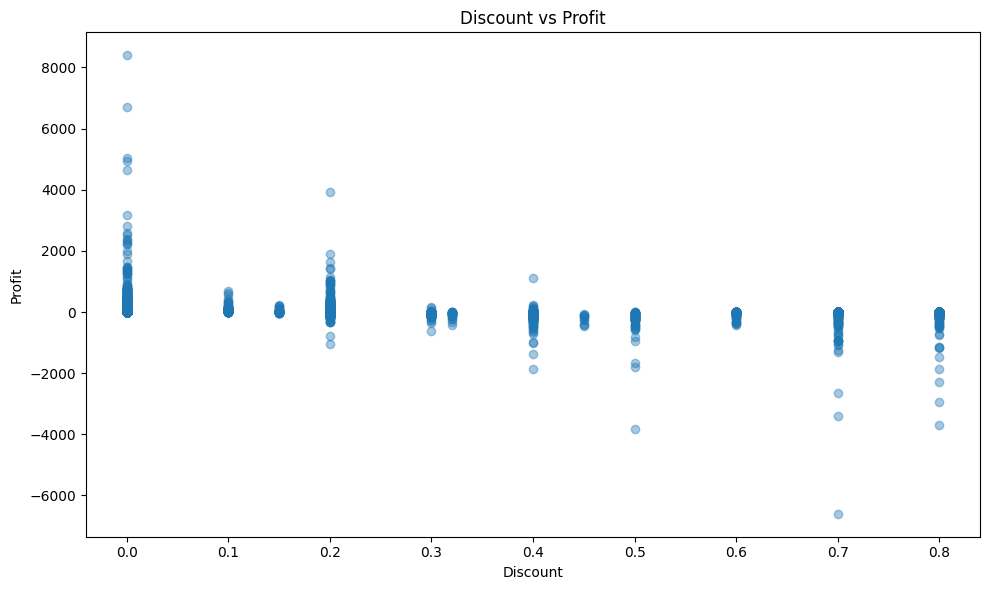

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['Discount'],
    df['Profit'],
    alpha=0.4
)

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

In [ ]:
shipping_performance = df.groupby('Ship Mode').agg(
    Orders=('Order ID', 'nunique'),
    Avg_Shipping_Days=('Shipping Days', 'mean'),
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).sort_values('Avg_Shipping_Days')

shipping_performance

,Orders,Avg_Shipping_Days,Sales,Profit
Ship Mode,,,,
Same Day,264,0.044199,1.283631e+05,15891.7589
First Class,787,2.182705,3.514284e+05,48969.8399
Second Class,964,3.238046,4.591936e+05,57446.6354
Standard Class,2994,5.006535,1.358216e+06,164088.7875


In [ ]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_quantity = df['Quantity'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()

In [ ]:
profit_margin = (total_profit / total_sales) * 100


In [ ]:
print("========== BUSINESS KPIs ==========")
print(f"Total Sales       : ${total_sales:,.2f}")
print(f"Total Profit      : ${total_profit:,.2f}")
print(f"Total Quantity    : {total_quantity:,}")
print(f"Total Orders      : {total_orders:,}")
print(f"Total Customers   : {total_customers:,}")
print(f"Profit Margin     : {profit_margin:.2f}%")

========== BUSINESS KPIs ==========
Total Sales       : $2,297,200.86
Total Profit      : $286,397.02
Total Quantity    : 37,873
Total Orders      : 5,009
Total Customers   : 793
Profit Margin     : 12.47%


In [ ]:
category_performance = df.groupby('Category').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).sort_values('Sales', ascending=False)

category_performance

,Sales,Profit,Quantity
Category,,,
Technology,836154.0330,145454.9481,6939
Furniture,741999.7953,18451.2728,8028
Office Supplies,719047.0320,122490.8008,22906


In [ ]:
category_performance['Profit Margin (%)'] = (
    category_performance['Profit']
    / category_performance['Sales']
) * 100

category_performance

,Sales,Profit,Quantity,Profit Margin (%)
Category,,,,
Technology,836154.0330,145454.9481,6939,17.395712
Furniture,741999.7953,18451.2728,8028,2.486695
Office Supplies,719047.0320,122490.8008,22906,17.035158


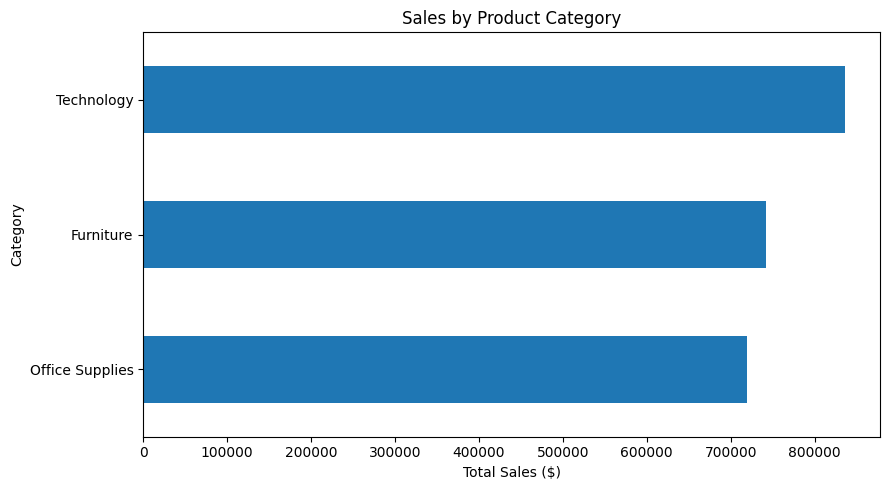

In [ ]:
plt.figure(figsize=(9, 5))

category_performance['Sales'].sort_values().plot(
    kind='barh'
)

plt.title('Sales by Product Category')
plt.xlabel('Total Sales ($)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

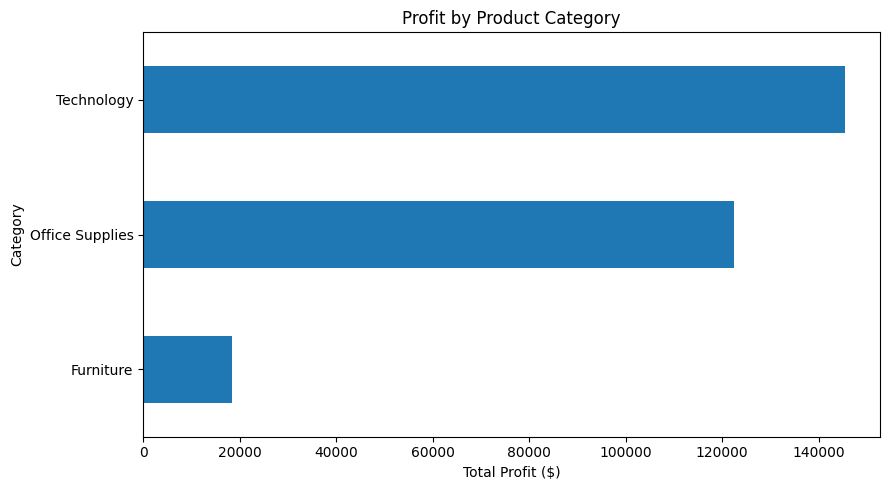

In [ ]:
plt.figure(figsize=(9, 5))

category_performance['Profit'].sort_values().plot(
    kind='barh'
)

plt.title('Profit by Product Category')
plt.xlabel('Total Profit ($)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [ ]:
region_performance = df.groupby('Region').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).sort_values('Sales', ascending=False)

region_performance

,Sales,Profit,Quantity
Region,,,
West,725457.8245,108418.4489,12266
East,678781.2400,91522.7800,10618
Central,501239.8908,39706.3625,8780
South,391721.9050,46749.4303,6209


In [ ]:
region_performance['Profit Margin (%)'] = (
    region_performance['Profit'] /
    region_performance['Sales']
) * 100

region_performance

,Sales,Profit,Quantity,Profit Margin (%)
Region,,,,
West,725457.8245,108418.4489,12266,14.944831
East,678781.2400,91522.7800,10618,13.483399
Central,501239.8908,39706.3625,8780,7.921629
South,391721.9050,46749.4303,6209,11.934342


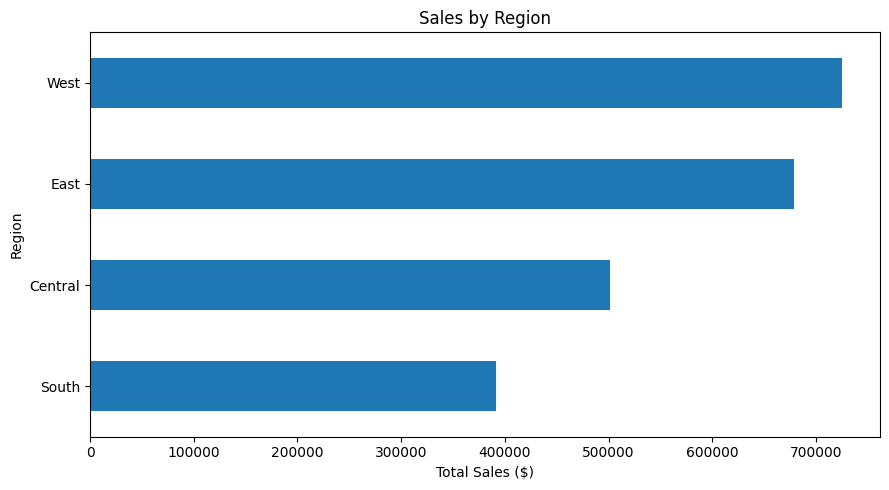

In [ ]:
plt.figure(figsize=(9, 5))

region_performance['Sales'].sort_values().plot(
    kind='barh'
)

plt.title('Sales by Region')
plt.xlabel('Total Sales ($)')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

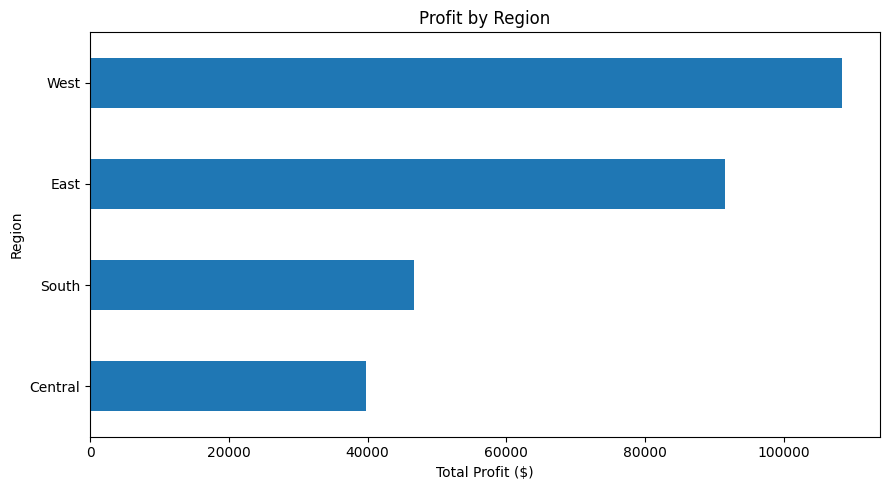

In [ ]:
plt.figure(figsize=(9, 5))

region_performance['Profit'].sort_values().plot(
    kind='barh'
)

plt.title('Profit by Region')
plt.xlabel('Total Profit ($)')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

In [ ]:
subcategory_performance = df.groupby('Sub-Category').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).sort_values('Profit')

subcategory_performance

,Sales,Profit,Quantity
Sub-Category,,,
Tables,206965.5320,-17725.4811,1241
Bookcases,114879.9963,-3472.5560,868
Supplies,46673.5380,-1189.0995,647
Fasteners,3024.2800,949.5182,914
Machines,189238.6310,3384.7569,440
Labels,12486.3120,5546.2540,1400
Art,27118.7920,6527.7870,3000
Envelopes,16476.4020,6964.1767,906
Furnishings,91705.1640,13059.1436,3563


In [ ]:
subcategory_performance['Profit Margin (%)'] = (
    subcategory_performance['Profit'] /
    subcategory_performance['Sales']
) * 100

subcategory_performance

,Sales,Profit,Quantity,Profit Margin (%)
Sub-Category,,,,
Tables,206965.5320,-17725.4811,1241,-8.564460
Bookcases,114879.9963,-3472.5560,868,-3.022768
Supplies,46673.5380,-1189.0995,647,-2.547695
Fasteners,3024.2800,949.5182,914,31.396504
Machines,189238.6310,3384.7569,440,1.788618
Labels,12486.3120,5546.2540,1400,44.418672
Art,27118.7920,6527.7870,3000,24.071083
Envelopes,16476.4020,6964.1767,906,42.267582
Furnishings,91705.1640,13059.1436,3563,14.240358


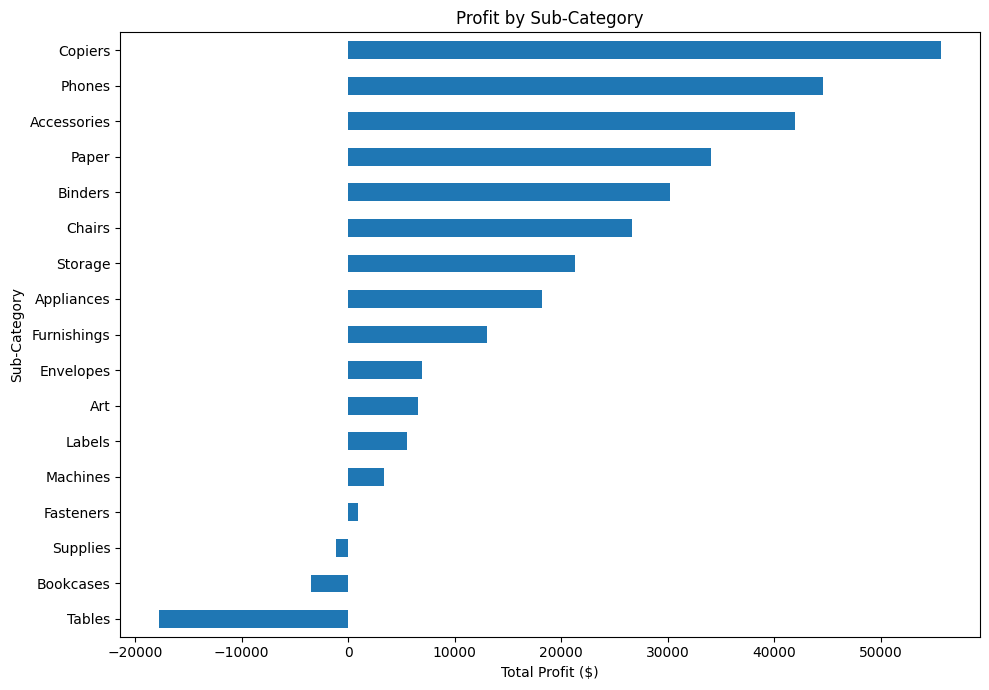

In [ ]:
plt.figure(figsize=(10, 7))

subcategory_performance['Profit'].sort_values().plot(
    kind='barh'
)

plt.title('Profit by Sub-Category')
plt.xlabel('Total Profit ($)')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()

In [ ]:
loss_making = subcategory_performance[
    subcategory_performance['Profit'] < 0
].sort_values('Profit')

loss_making

,Sales,Profit,Quantity,Profit Margin (%)
Sub-Category,,,,
Tables,206965.5320,-17725.4811,1241,-8.564460
Bookcases,114879.9963,-3472.5560,868,-3.022768
Supplies,46673.5380,-1189.0995,647,-2.547695


In [ ]:
top_profitable = subcategory_performance.sort_values(
    'Profit',
    ascending=False
).head(5)

top_profitable

,Sales,Profit,Quantity,Profit Margin (%)
Sub-Category,,,,
Copiers,149528.030,55617.8249,234,37.195585
Phones,330007.054,44515.7306,3289,13.489327
Accessories,167380.318,41936.6357,2976,25.054700
Paper,78479.206,34053.5693,5178,43.391837
Binders,203412.733,30221.7633,5974,14.857361


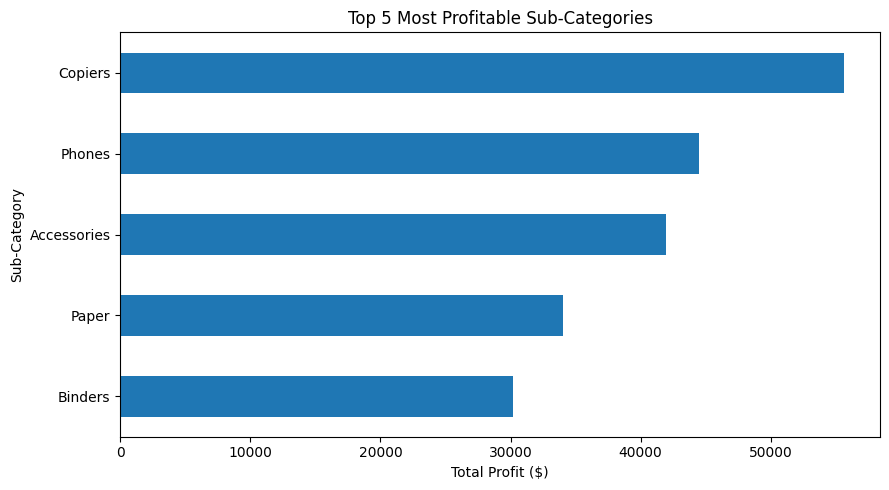

In [ ]:
plt.figure(figsize=(9, 5))

top_profitable['Profit'].sort_values().plot(
    kind='barh'
)

plt.title('Top 5 Most Profitable Sub-Categories')
plt.xlabel('Total Profit ($)')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

print(df['Order Date'].dtype)

datetime64[ns]


In [ ]:
df['Month'] = df['Order Date'].dt.to_period('M')

In [ ]:
monthly_performance = df.groupby('Month').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
)

monthly_performance.head()

,Sales,Profit
Month,,
2014-01,14236.895,2450.1907
2014-02,4519.892,862.3084
2014-03,55691.009,498.7299
2014-04,28295.345,3488.8352
2014-05,23648.287,2738.7096


In [ ]:
monthly_performance.index = monthly_performance.index.to_timestamp()

monthly_performance.head()

,Sales,Profit
Month,,
2014-01-01,14236.895,2450.1907
2014-02-01,4519.892,862.3084
2014-03-01,55691.009,498.7299
2014-04-01,28295.345,3488.8352
2014-05-01,23648.287,2738.7096


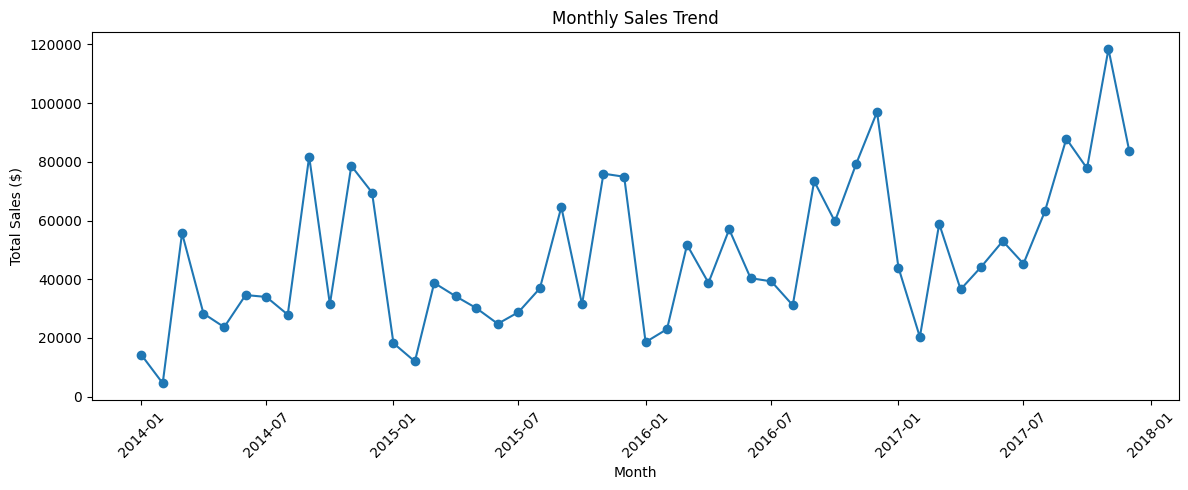

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_performance.index,
    monthly_performance['Sales'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

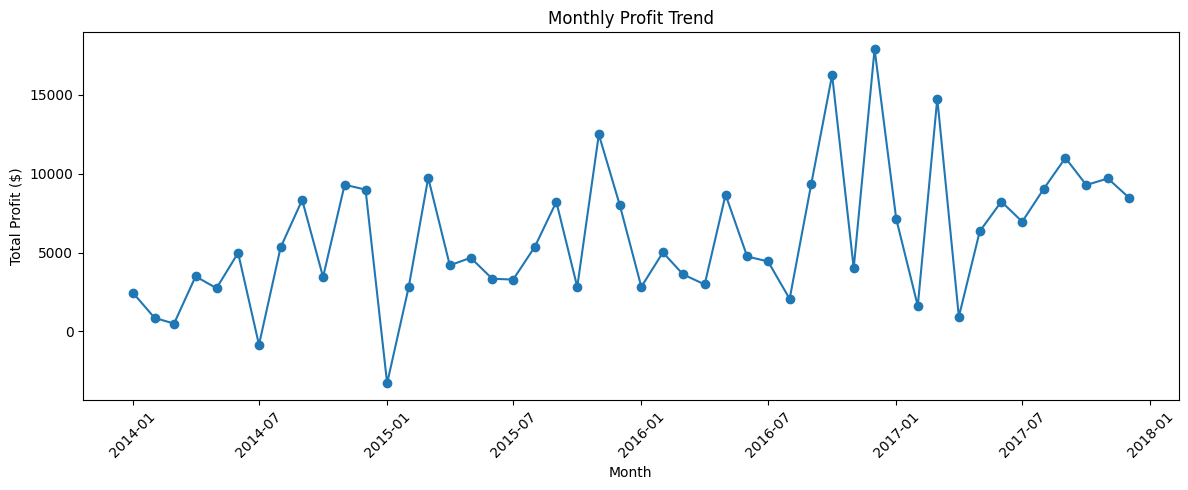

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_performance.index,
    monthly_performance['Profit'],
    marker='o'
)

plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Total Profit ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
best_sales_month = monthly_performance['Sales'].idxmax()

print("Highest Sales Month:")
print(best_sales_month)
print("Sales: $", round(monthly_performance.loc[best_sales_month, 'Sales'], 2))

Highest Sales Month:
2017-11-01 00:00:00
Sales: $ 118447.82


In [ ]:
worst_profit_month = monthly_performance['Profit'].idxmin()

print("Lowest Profit Month:")
print(worst_profit_month)
print("Profit: $", round(monthly_performance.loc[worst_profit_month, 'Profit'], 2))

Lowest Profit Month:
2015-01-01 00:00:00
Profit: $ -3281.01


In [ ]:
df['Discount Group'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0, 0.10, 0.20, 0.30, 0.50, 1.0],
    labels=[
        'No Discount',
        '1-10%',
        '11-20%',
        '21-30%',
        '31-50%',
        '50%+'
    ]
)

df['Discount Group'].value_counts().sort_index()

,count
Discount Group,
No Discount,4798
1-10%,94
11-20%,3709
21-30%,227
31-50%,310
50%+,856


In [ ]:
discount_analysis = df.groupby('Discount Group', observed=True).agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
)

discount_analysis['Profit Margin (%)'] = (
    discount_analysis['Profit'] /
    discount_analysis['Sales']
) * 100

discount_analysis

,Sales,Profit,Quantity,Profit Margin (%)
Discount Group,,,,
No Discount,1.087908e+06,320987.6032,18267,29.505019
1-10%,5.436935e+04,9029.1770,373,16.607108
11-20%,7.921529e+05,91756.2975,13858,11.583155
21-30%,1.032267e+05,-10369.2774,849,-10.045155
31-50%,1.953148e+05,-48447.7273,1177,-24.804950
50%+,6.422874e+04,-76559.0513,3349,-119.197502


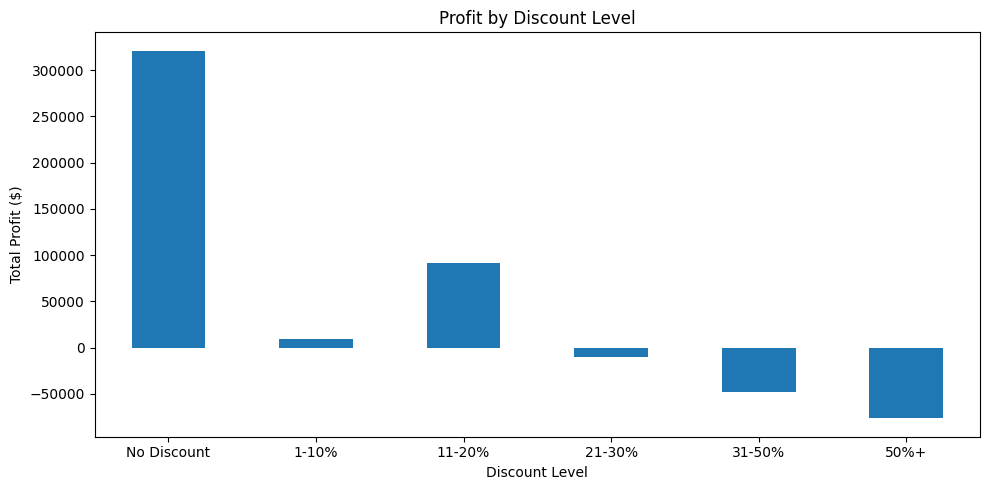

In [ ]:
plt.figure(figsize=(10, 5))

discount_analysis['Profit'].plot(
    kind='bar'
)

plt.title('Profit by Discount Level')
plt.xlabel('Discount Level')
plt.ylabel('Total Profit ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
worst_discount = discount_analysis['Profit'].idxmin()

print("Most Loss-Making Discount Level:", worst_discount)
print(
    "Profit: $",
    round(discount_analysis.loc[worst_discount, 'Profit'], 2)
)

Most Loss-Making Discount Level: 50%+
Profit: $ -76559.05


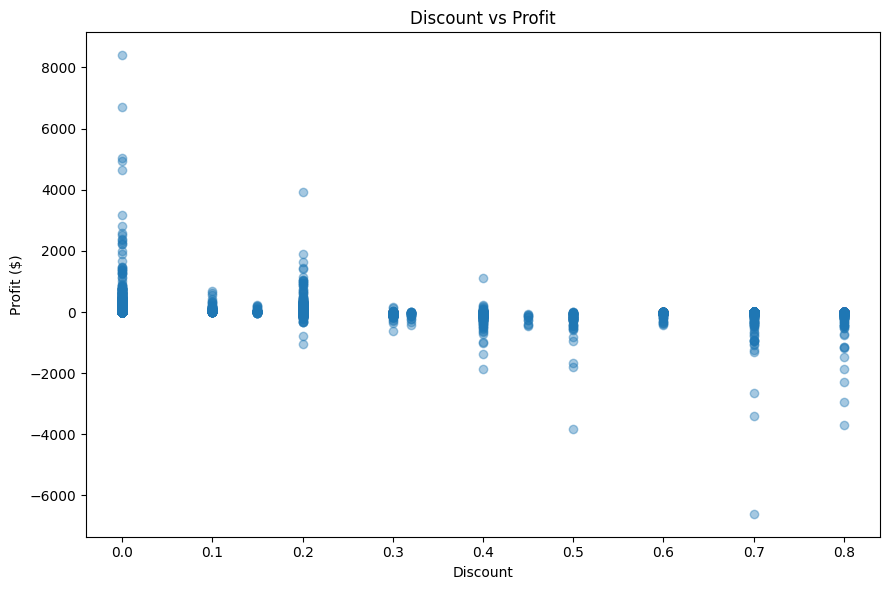

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df['Discount'],
    df['Profit'],
    alpha=0.4
)

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.show()

In [ ]:
correlation = df['Discount'].corr(df['Profit'])

print("Correlation between Discount and Profit:", round(correlation, 3))

Correlation between Discount and Profit: -0.219


In [ ]:
segment_performance = df.groupby('Segment').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum'),
    Orders=('Order ID', 'nunique'),
    Customers=('Customer ID', 'nunique')
).sort_values('Sales', ascending=False)

segment_performance

,Sales,Profit,Quantity,Orders,Customers
Segment,,,,,
Consumer,1.161401e+06,134119.2092,19521,2586,409
Corporate,7.061464e+05,91979.1340,11608,1514,236
Home Office,4.296531e+05,60298.6785,6744,909,148


In [ ]:
segment_performance['Profit Margin (%)'] = (
    segment_performance['Profit'] /
    segment_performance['Sales']
) * 100

segment_performance

,Sales,Profit,Quantity,Orders,Customers,Profit Margin (%)
Segment,,,,,,
Consumer,1.161401e+06,134119.2092,19521,2586,409,11.548050
Corporate,7.061464e+05,91979.1340,11608,1514,236,13.025506
Home Office,4.296531e+05,60298.6785,6744,909,148,14.034269


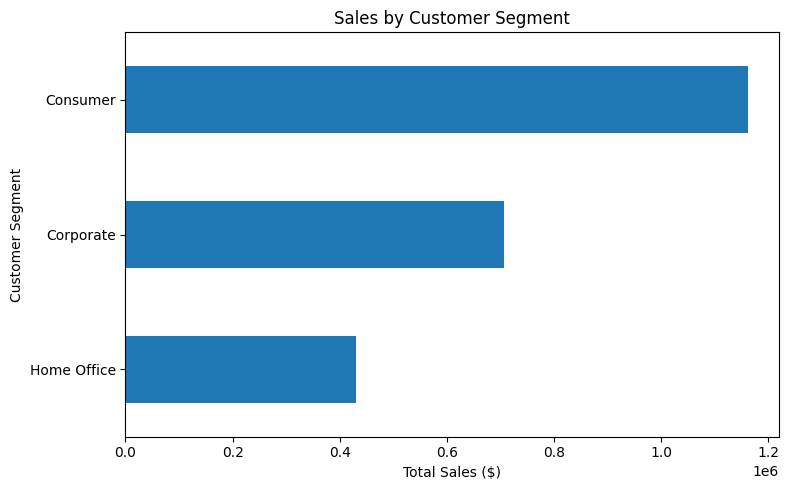

In [ ]:
plt.figure(figsize=(8, 5))

segment_performance['Sales'].sort_values().plot(
    kind='barh'
)

plt.title('Sales by Customer Segment')
plt.xlabel('Total Sales ($)')
plt.ylabel('Customer Segment')
plt.tight_layout()
plt.show()

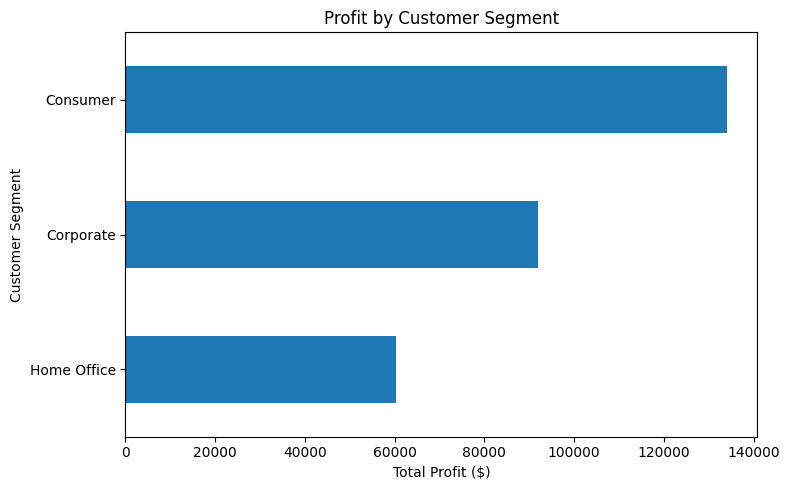

In [ ]:
plt.figure(figsize=(8, 5))

segment_performance['Profit'].sort_values().plot(
    kind='barh'
)

plt.title('Profit by Customer Segment')
plt.xlabel('Total Profit ($)')
plt.ylabel('Customer Segment')
plt.tight_layout()
plt.show()

In [ ]:
top_products_sales = df.groupby('Product Name').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).sort_values('Sales', ascending=False).head(10)

top_products_sales

,Sales,Profit,Quantity
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04,20
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7.753039e+03,31
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1.811078e+03,6
HON 5400 Series Task Chairs for Big and Tall,21870.576,5.684342e-14,39
GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03,37
GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02,48
Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03,38
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4.094977e+03,12
GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03,27


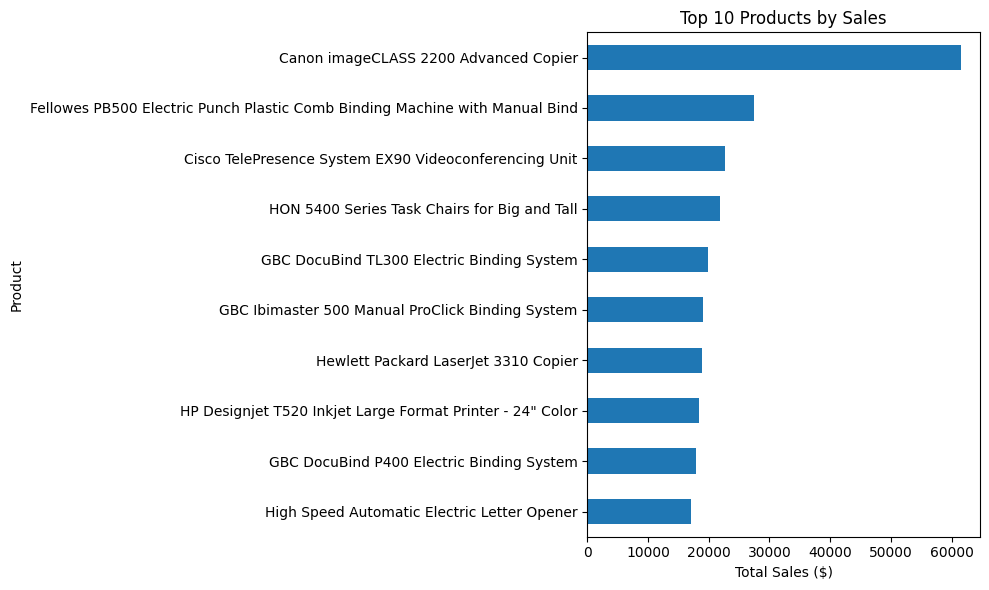

In [ ]:
plt.figure(figsize=(10, 6))

top_products_sales['Sales'].sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [ ]:
top_products_profit = df.groupby('Product Name').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).sort_values('Profit', ascending=False).head(10)

top_products_profit

,Sales,Profit,Quantity
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280,20
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7753.0390,31
Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836,38
Canon PC1060 Personal Laser Copier,11619.834,4570.9347,19
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4094.9766,12
Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461,11
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714,11
Plantronics Savi W720 Multi-Device Wireless Headset System,9367.290,3696.2820,24
Ibico EPK-21 Electric Binding System,15875.916,3345.2823,13


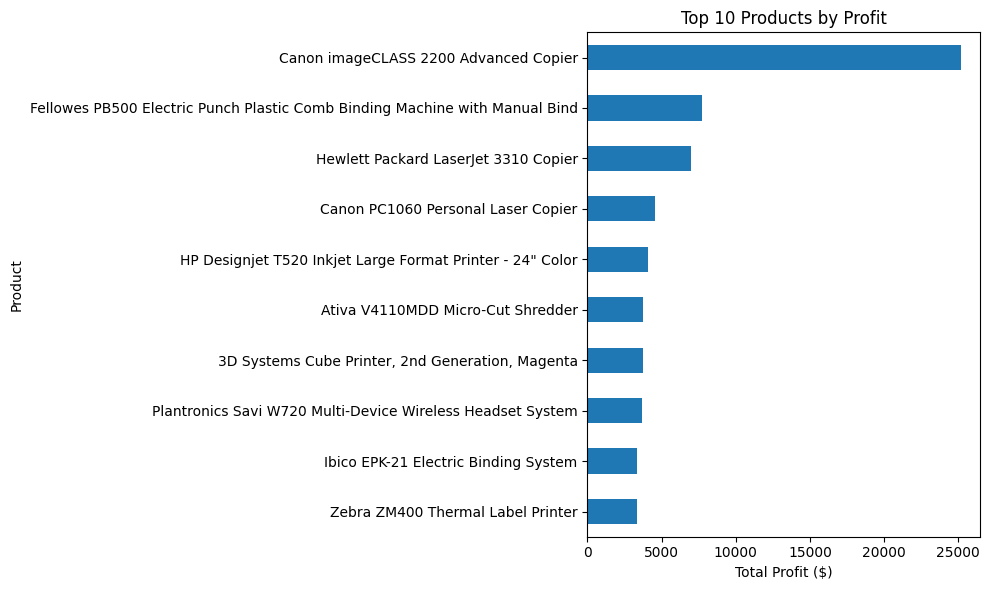

In [ ]:
plt.figure(figsize=(10, 6))

top_products_profit['Profit'].sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Products by Profit')
plt.xlabel('Total Profit ($)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [ ]:
bottom_products_profit = df.groupby('Product Name').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).sort_values('Profit').head(10)

bottom_products_profit

,Sales,Profit,Quantity
Product Name,,,
Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9
Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18
Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156,27
Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976,33
GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784,6
Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836,22
Balt Solid Wood Round Tables,6518.754,-1201.0581,19


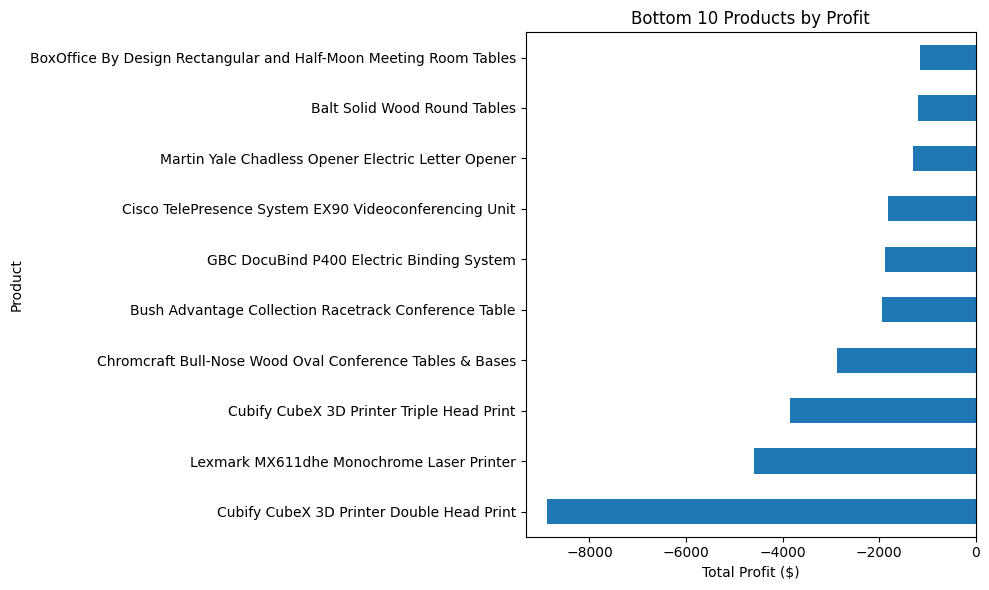

In [ ]:
plt.figure(figsize=(10, 6))

bottom_products_profit['Profit'].sort_values().plot(
    kind='barh'
)

plt.title('Bottom 10 Products by Profit')
plt.xlabel('Total Profit ($)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [ ]:
top_customers = df.groupby(
    ['Customer ID', 'Customer Name']
).agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).sort_values('Sales', ascending=False).head(10)

top_customers

,,Sales,Profit,Orders
Customer ID,Customer Name,,,
SM-20320,Sean Miller,25043.050,-1980.7393,5
TC-20980,Tamara Chand,19052.218,8981.3239,5
RB-19360,Raymond Buch,15117.339,6976.0959,6
TA-21385,Tom Ashbrook,14595.620,4703.7883,4
AB-10105,Adrian Barton,14473.571,5444.8055,10
KL-16645,Ken Lonsdale,14175.229,806.8550,12
SC-20095,Sanjit Chand,14142.334,5757.4119,9
HL-15040,Hunter Lopez,12873.298,5622.4292,6
SE-20110,Sanjit Engle,12209.438,2650.6769,11


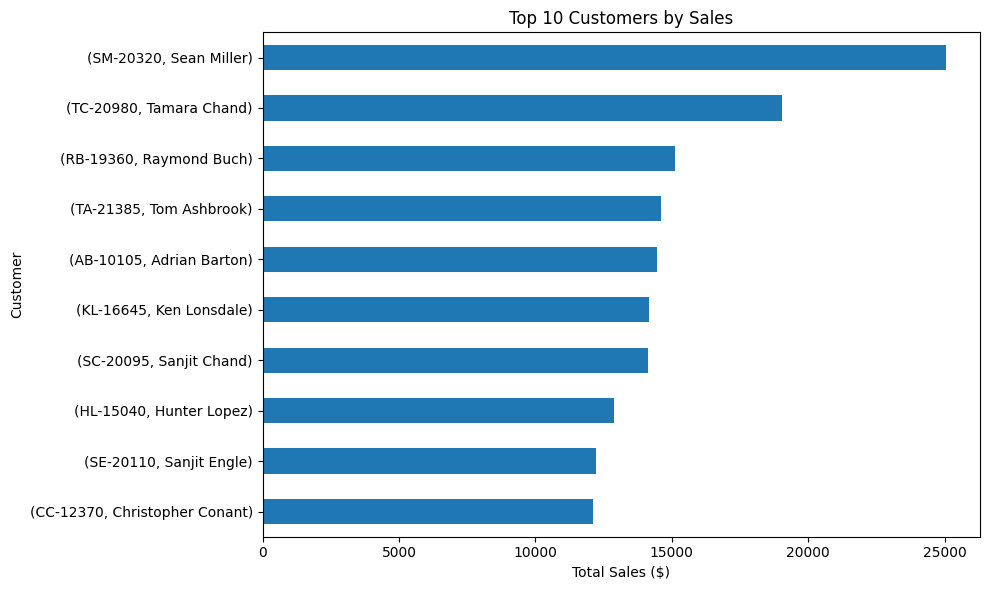

In [ ]:
plt.figure(figsize=(10, 6))

top_customers['Sales'].sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Customers by Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('Customer')
plt.tight_layout()
plt.show()